In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
import warnings
warnings.filterwarnings('ignore')

# Make charts look nice
plt.style.use('seaborn-v0_8')

print("✅ All libraries imported!") 

✅ All libraries imported!


In [2]:
# Load the master index
BASE_DIR = os.path.join(os.getcwd(), '..')
df = pd.read_csv(os.path.join(BASE_DIR, 'data', 'splits', 'all_docs.csv'))

# Read the actual text content of each document
def read_doc(filepath):
    full_path = os.path.join(BASE_DIR, filepath)
    with open(full_path, 'r') as f:
        return f.read()

df['text'] = df['file_path'].apply(read_doc)

print(f"✅ Loaded {len(df)} documents")
print(f"\nFirst few rows:")
print(df[['class_label', 'word_count']].head(10))

✅ Loaded 100 documents

First few rows:
  class_label  word_count
0     Invoice          54
1     Invoice          56
2     Invoice          55
3     Invoice          57
4     Invoice          59
5     Invoice          55
6     Invoice          55
7     Invoice          57
8     Invoice          55
9     Invoice          57


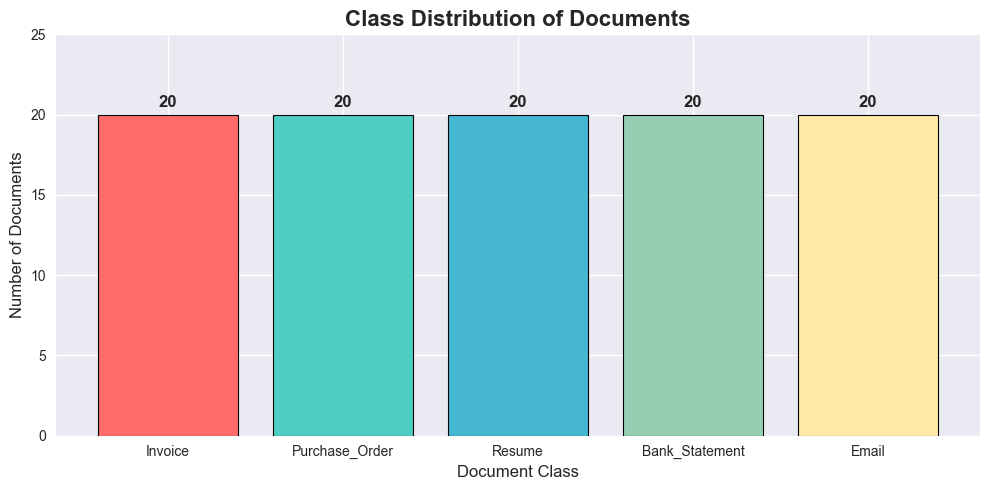

✅ Chart saved to outputs/


In [3]:
# Count how many documents per class
class_counts = df['class_label'].value_counts()

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(class_counts.index, class_counts.values, 
              color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7'],
              edgecolor='black', linewidth=0.8)

# Add count labels on top of each bar
for bar, count in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(count), ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.set_title('Class Distribution of Documents', fontsize=16, fontweight='bold')
ax.set_xlabel('Document Class', fontsize=12)
ax.set_ylabel('Number of Documents', fontsize=12)
ax.set_ylim(0, 25)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'outputs', 'class_distribution.png'))
plt.show()
print("✅ Chart saved to outputs/")

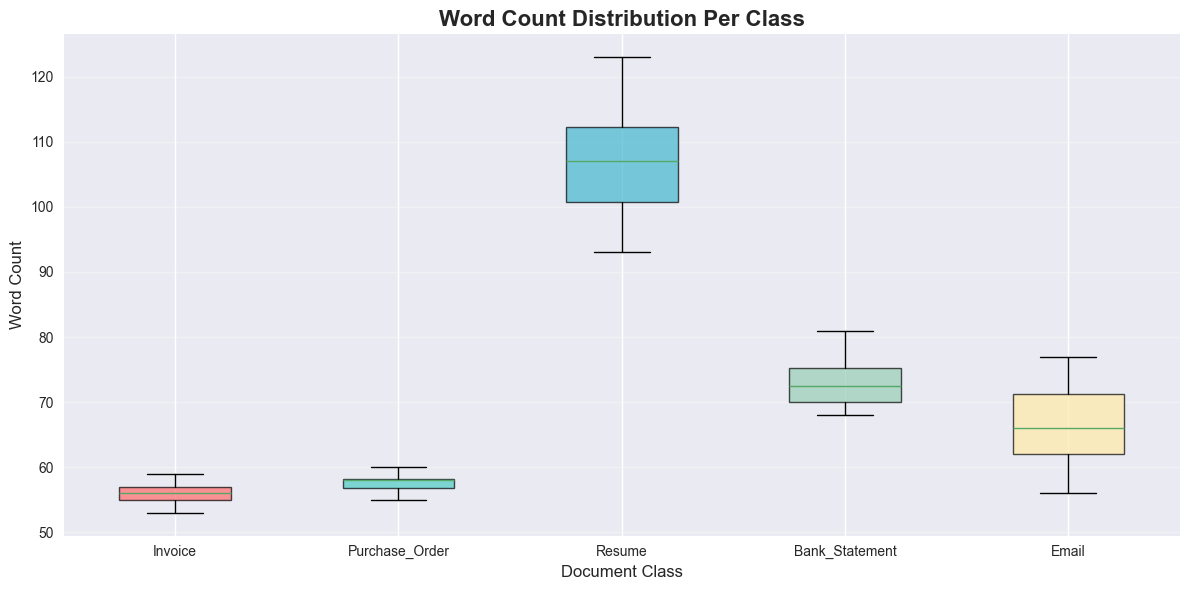

📊 Word Count Summary Per Class:
                count   mean  std   min    25%    50%    75%    max
class_label                                                        
Bank_Statement   20.0   73.0  3.5  68.0   70.0   72.5   75.2   81.0
Email            20.0   66.4  5.7  56.0   62.0   66.0   71.2   77.0
Invoice          20.0   56.0  1.8  53.0   55.0   56.0   57.0   59.0
Purchase_Order   20.0   57.6  1.4  55.0   56.8   58.0   58.2   60.0
Resume           20.0  107.2  8.5  93.0  100.8  107.0  112.2  123.0


In [4]:
# Box plot of word counts per class
fig, ax = plt.subplots(figsize=(12, 6))

# Get data for each class
data_per_class = [df[df['class_label'] == cls]['word_count'].values 
                  for cls in df['class_label'].unique()]

bp = ax.boxplot(data_per_class, 
                labels=df['class_label'].unique(),
                patch_artist=True,
                notch=False)

# Color each box differently
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Word Count Distribution Per Class', fontsize=16, fontweight='bold')
ax.set_xlabel('Document Class', fontsize=12)
ax.set_ylabel('Word Count', fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'outputs', 'word_count_distribution.png'))
plt.show()

# Print summary stats
print("📊 Word Count Summary Per Class:")
print(df.groupby('class_label')['word_count'].describe().round(1))

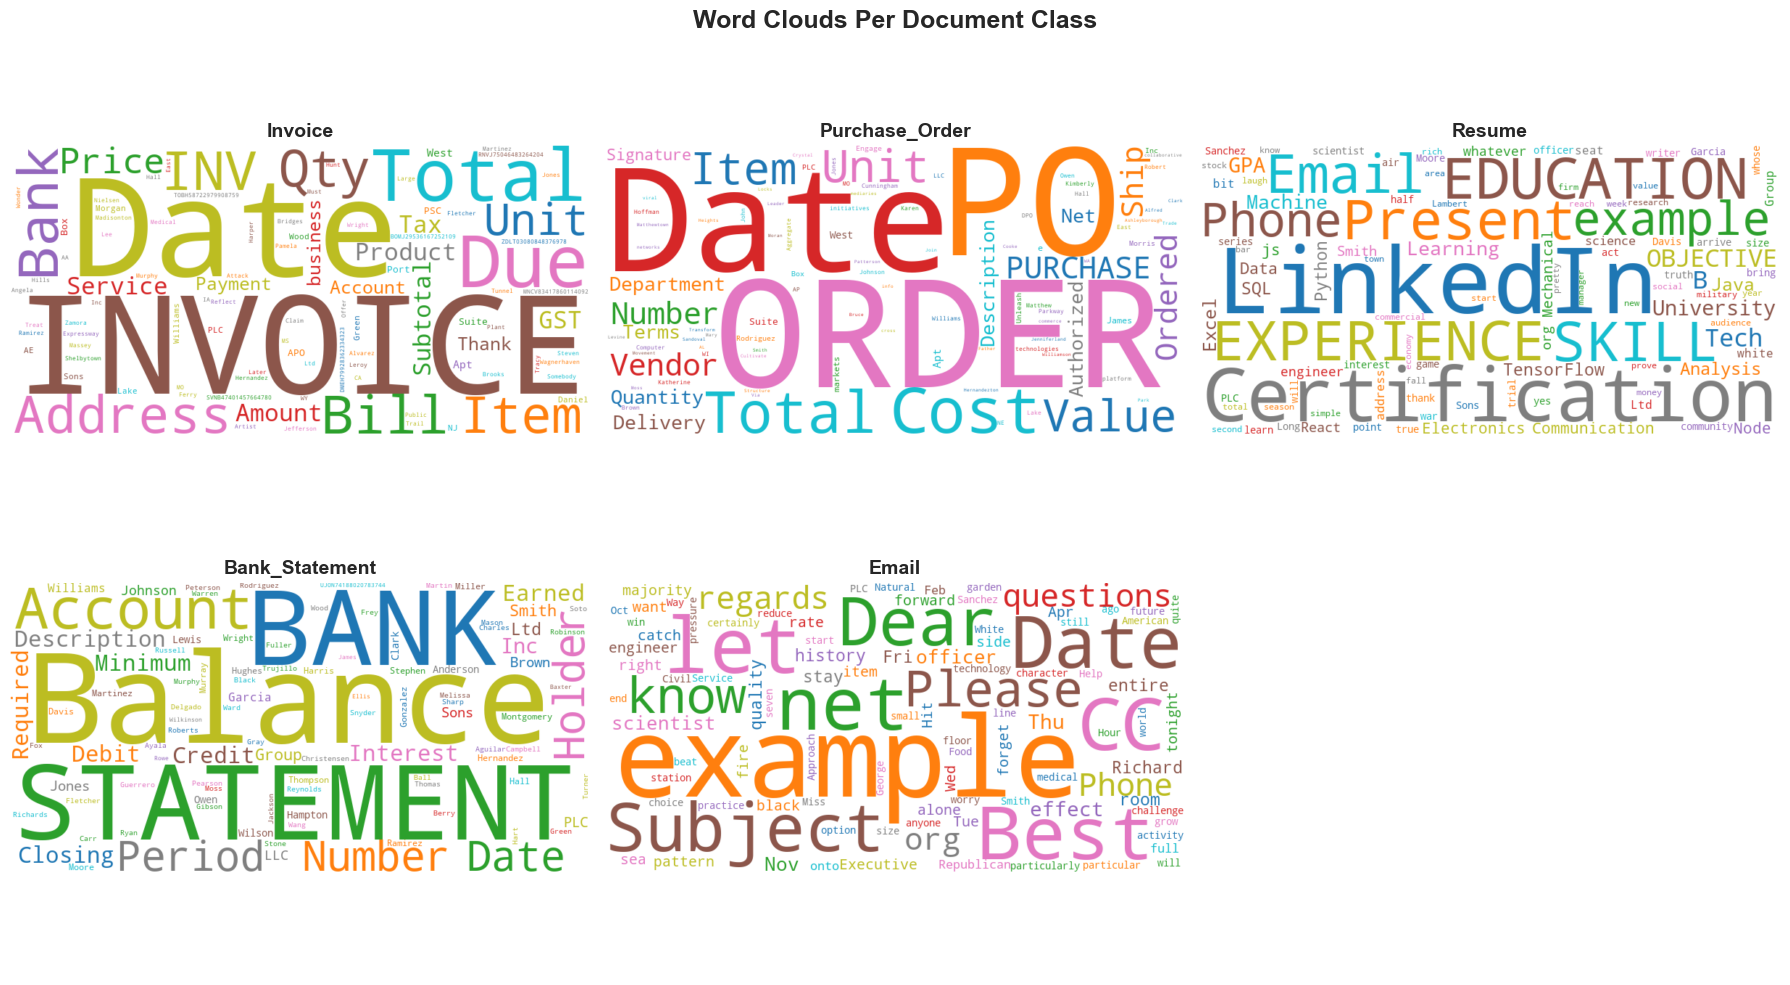

✅ Word clouds saved!


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

classes = df['class_label'].unique()

for i, cls in enumerate(classes):
    # Get all text for this class joined together
    all_text = ' '.join(df[df['class_label'] == cls]['text'].values)
    
    # Generate word cloud
    wc = WordCloud(
        width=800, height=400,
        background_color='white',
        max_words=100,
        colormap='tab10',
        collocations=False
    ).generate(all_text)
    
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f'{cls}', fontsize=14, fontweight='bold')
    axes[i].axis('off')

# Hide the 6th empty subplot
axes[5].axis('off')

plt.suptitle('Word Clouds Per Document Class', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'outputs', 'wordclouds.png'))
plt.show()
print("✅ Word clouds saved!")

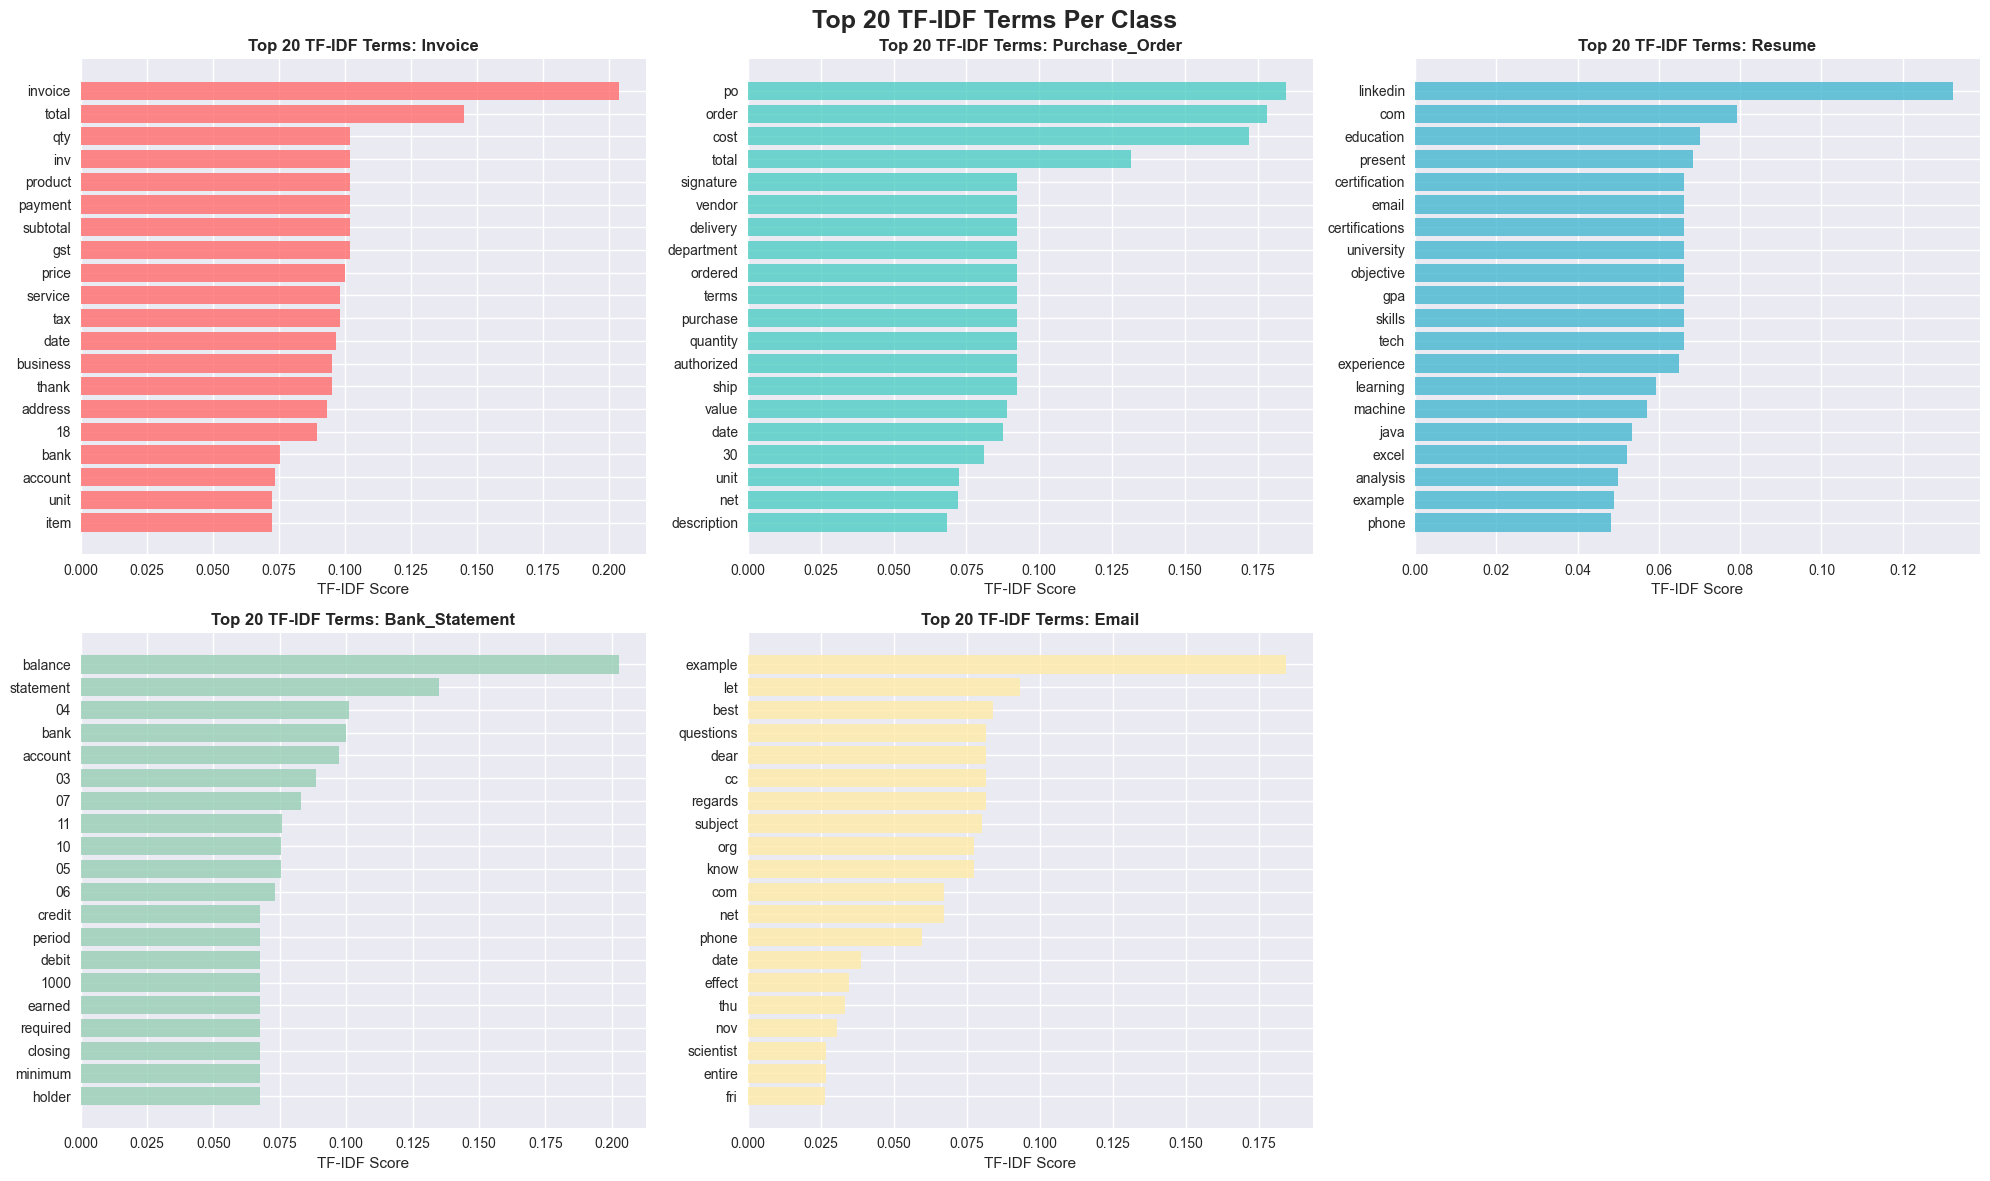

✅ TF-IDF chart saved!


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# Fit TF-IDF on all documents
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
tfidf_matrix = vectorizer.fit_transform(df['text'])
feature_names = vectorizer.get_feature_names_out()

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

classes = df['class_label'].unique()

for i, cls in enumerate(classes):
    # Get indices of documents belonging to this class
    class_indices = df[df['class_label'] == cls].index
    
    # Average TF-IDF score for each word across this class
    class_tfidf = tfidf_matrix[class_indices].mean(axis=0)
    class_tfidf = np.asarray(class_tfidf).flatten()
    
    # Get top 20 words
    top_indices = class_tfidf.argsort()[-20:][::-1]
    top_words   = [feature_names[j] for j in top_indices]
    top_scores  = [class_tfidf[j]   for j in top_indices]
    
    # Plot horizontal bar chart
    axes[i].barh(top_words[::-1], top_scores[::-1], color=colors[i], alpha=0.8)
    axes[i].set_title(f'Top 20 TF-IDF Terms: {cls}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('TF-IDF Score')

# Hide 6th subplot
axes[5].axis('off')

plt.suptitle('Top 20 TF-IDF Terms Per Class', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'outputs', 'tfidf_top_terms.png'))
plt.show()
print("✅ TF-IDF chart saved!")

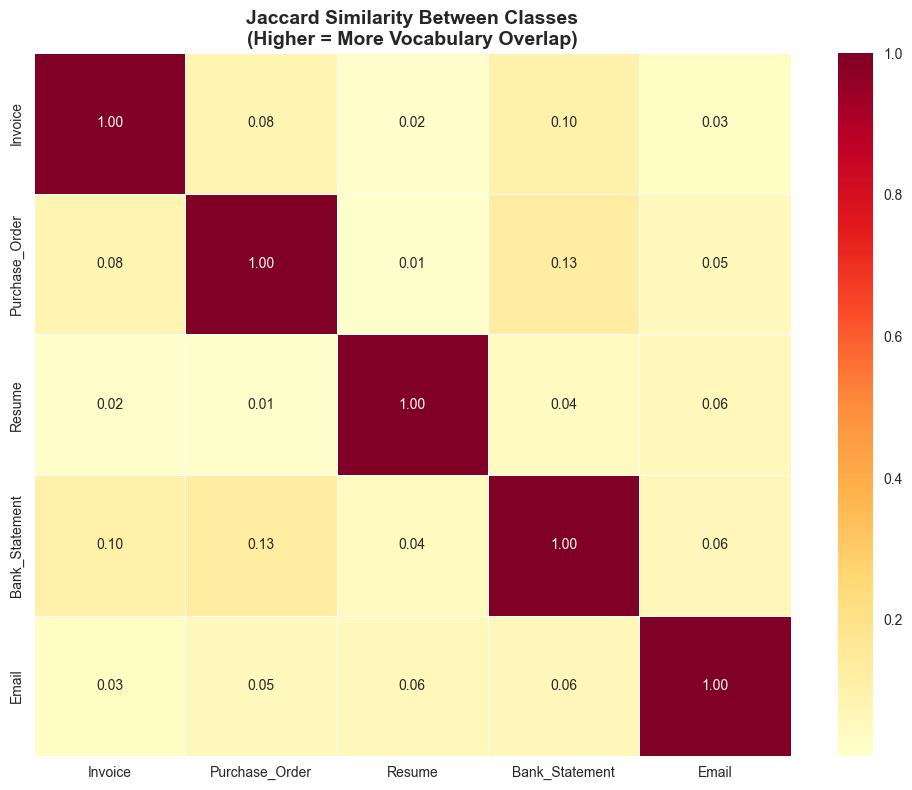

⚠️  Most similar class pair: Purchase_Order & Bank_Statement
   Jaccard similarity: 0.13

💡 These two classes will likely be hardest for the ML model to tell apart!


In [7]:
from sklearn.metrics import jaccard_score

# Get top 200 words for each class
top_words_per_class = {}

for cls in classes:
    class_indices = df[df['class_label'] == cls].index
    class_tfidf = tfidf_matrix[class_indices].mean(axis=0)
    class_tfidf = np.asarray(class_tfidf).flatten()
    top_indices = class_tfidf.argsort()[-200:][::-1]
    top_words_per_class[cls] = set([feature_names[j] for j in top_indices])

# Compute Jaccard similarity between every pair of classes
n = len(classes)
jaccard_matrix = np.zeros((n, n))

for i, cls1 in enumerate(classes):
    for j, cls2 in enumerate(classes):
        set1 = top_words_per_class[cls1]
        set2 = top_words_per_class[cls2]
        intersection = len(set1 & set2)
        union = len(set1 | set2)
        jaccard_matrix[i][j] = intersection / union

# Plot heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(jaccard_matrix,
            annot=True,
            fmt='.2f',
            xticklabels=classes,
            yticklabels=classes,
            cmap='YlOrRd',
            linewidths=0.5,
            ax=ax)

ax.set_title('Jaccard Similarity Between Classes\n(Higher = More Vocabulary Overlap)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'outputs', 'jaccard_heatmap.png'))
plt.show()

# Find the most confused pair
max_sim = 0
confused_pair = ('', '')
for i, cls1 in enumerate(classes):
    for j, cls2 in enumerate(classes):
        if i != j and jaccard_matrix[i][j] > max_sim:
            max_sim = jaccard_matrix[i][j]
            confused_pair = (cls1, cls2)

print(f"⚠️  Most similar class pair: {confused_pair[0]} & {confused_pair[1]}")
print(f"   Jaccard similarity: {max_sim:.2f}")
print(f"\n💡 These two classes will likely be hardest for the ML model to tell apart!")

In [8]:
# Final summary statistics
print("=" * 55)
print("         EDA SUMMARY REPORT")
print("=" * 55)

print(f"\n📁 Total Documents      : {len(df)}")
print(f"📂 Number of Classes    : {df['class_label'].nunique()}")
print(f"📄 Docs per Class       : 20 (balanced)")

print(f"\n📊 Word Count Stats:")
print(f"   Shortest class : {df.groupby('class_label')['word_count'].mean().idxmin()}")
print(f"   Longest class  : {df.groupby('class_label')['word_count'].mean().idxmax()}")
print(f"   Overall avg    : {df['word_count'].mean():.1f} words per doc")
print(f"   Overall min    : {df['word_count'].min()} words")
print(f"   Overall max    : {df['word_count'].max()} words")

print(f"\n🔤 TF-IDF Vocabulary    : {len(feature_names)} unique terms")

print(f"\n⚠️  Most Similar Classes : {confused_pair[0]} & {confused_pair[1]}")
print(f"   Jaccard Similarity   : {max_sim:.2f}")
print(f"   → These may be hardest to classify correctly")

print(f"\n✅ Key Insight:")
print(f"   Low Jaccard scores (all < 0.20) suggest classes")
print(f"   are well separated in vocabulary space.")
print(f"   Classical TF-IDF + ML should perform well!")

print("\n" + "=" * 55)
print("   EDA Complete — Ready for Feature Engineering!")
print("=" * 55)

         EDA SUMMARY REPORT

📁 Total Documents      : 100
📂 Number of Classes    : 5
📄 Docs per Class       : 20 (balanced)

📊 Word Count Stats:
   Shortest class : Invoice
   Longest class  : Resume
   Overall avg    : 72.1 words per doc
   Overall min    : 53 words
   Overall max    : 123 words

🔤 TF-IDF Vocabulary    : 2478 unique terms

⚠️  Most Similar Classes : Purchase_Order & Bank_Statement
   Jaccard Similarity   : 0.13
   → These may be hardest to classify correctly

✅ Key Insight:
   Low Jaccard scores (all < 0.20) suggest classes
   are well separated in vocabulary space.
   Classical TF-IDF + ML should perform well!

   EDA Complete — Ready for Feature Engineering!
